In [1]:
from SalesInsight import SalesInsight
import pandas as pd
import numpy as np
from gerador_dataset import gerar_dataset_vendas

Etapa 1 - Criando o dataset de vendas

In [2]:
si = SalesInsight(pd, np)

dataset_vendas = si.carregar_dicionario(gerar_dataset_vendas())
    
    
dataset_vendas.head()

[SalesInsight] Dicionário convertido para DataFrame
Registros carregados: 200


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2.0,102.90
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7.0,214.88
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4.0,2501.76
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8.0,121.30


Etapa 2 - Inspecionando e exibindo as informações no dataset

#Para correção do código do exemplo, foi necessário corrigir a identação e chamar a função df_bruto para impressao.

In [3]:
si.inspecionar_dados(dataset_vendas)

=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (200, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda            int64
data_venda            str
cliente               str
produto               str
categoria             str
regiao                str
quantidade        float64
preco_unitario    float64
dtype: object

Valores nulos por coluna:
id_venda           0
data_venda         0
cliente            0
produto            0
categoria          0
regiao             0
quantidade         6
preco_unitario    10
dtype: int64

Primeiros registros:
   id_venda  data_venda      cliente     produto     categoria    regiao  \
0         1  2024-05-20  Cliente_035       Mouse   Periféricos   Sudeste   
1         2  2024-02-17  Cliente_042     Teclado   Periféricos     Norte   
2         3  2024-05-22  Cliente_022     Monitor  Computadores  Nordeste   
3         4  2024-06-21  Cliente_017  Smartphone     Celulare

Etapa 3 - Limpeza e tratamento dos dados
"""
Neste bloco vamos: 
-Remover ou imputar linhas com valores nulos nas colunas críticas (quantidade, preco_unitario);
-Remover linhas com datas inválidas (ex.: "DATA INVÁLIDA");
-Converter a coluna de data para o tipo datetime;
-Remover espaços extras em colunas de texto com .str.strip();
-Registrar no console quantos registros foram removidos."""


Necessário chamar a função para exibir o relatório. Também, anulou-se a função import re e geramos a inspeção do relatório, agora limpo.

In [4]:
df_limpo, relatorio_limpeza = si.limpar_dados(dataset_vendas)


=== RELATÓRIO DE LIMPEZA ===
  datas_invalidas_removidas: 4
  linhas_nulas_removidas: 16
  registros_iniciais: 200
  registros_finais: 180
  registros_removidos_total: 20


In [5]:
df_limpo.head()

,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2,102.90
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7,214.88
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4,2501.76
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8,121.30
5,6,2024-04-26,Cliente_025,Smartphone,Celulares,Nordeste,2,1900.24


In [6]:
si.inspecionar_dados(df_limpo)

=== INSPEÇÃO INICIAL DO DATASET ===
Shape: (180, 8)

Colunas: ['id_venda', 'data_venda', 'cliente', 'produto', 'categoria', 'regiao', 'quantidade', 'preco_unitario']

Tipos de dados:
id_venda                   int64
data_venda        datetime64[us]
cliente                      str
produto                      str
categoria                    str
regiao                       str
quantidade                 int64
preco_unitario           float64
dtype: object

Valores nulos por coluna:
id_venda          0
data_venda        0
cliente           0
produto           0
categoria         0
regiao            0
quantidade        0
preco_unitario    0
dtype: int64

Primeiros registros:
   id_venda data_venda      cliente     produto    categoria    regiao  \
0         1 2024-05-20  Cliente_035       Mouse  Periféricos   Sudeste   
1         2 2024-02-17  Cliente_042     Teclado  Periféricos     Norte   
3         4 2024-06-21  Cliente_017  Smartphone    Celulares   Sudeste   
4         5 2024-07-1

Etapa 4 - Criando colunas derivadas com transformações
""" 
Neste bloco o objetivo é enriquecer o dataset para análise gerando novas colunas a partir do dados existentes, como:
- receita_total: quantidade * preco_unitario
- mes: mês extraído da data (número ou nome)
- trimestre: trimestre do ano (Q1, Q2, Q3, Q4)
- ano: ano extraído da data
- faixa_receita_item: classificação da receita por item usando transformação condicional"""


In [7]:
df_processado = si.criar_colunas_derivadas(df_limpo)
df_processado.head()


=== COLUNAS DERIVADAS CRIADAS ===
  data_venda  receita_total  mes trimestre faixa_receita_item
0 2024-05-20         205.80    5        Q2        Baixo Valor
1 2024-02-17        1504.16    2        Q1        Médio Valor
3 2024-06-21       10007.04    6        Q2         Alto Valor
4 2024-07-12         970.40    7        Q3        Médio Valor
5 2024-04-26        3800.48    4        Q2        Médio Valor


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2,102.90,205.80,5,May,Q2,2024,Baixo Valor
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7,214.88,1504.16,2,February,Q1,2024,Médio Valor
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4,2501.76,10007.04,6,June,Q2,2024,Alto Valor
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8,121.30,970.40,7,July,Q3,2024,Médio Valor
5,6,2024-04-26,Cliente_025,Smartphone,Celulares,Nordeste,2,1900.24,3800.48,4,April,Q2,2024,Médio Valor


Etapa 5 - Calculo de métricas agrupadas
"""
Neste bloco, apresentamos as informações a seguir:
-Receita total e quantidade vendida por mês;
-Receita total por produto (top 5);
-Receita total por categoria;
-Receita total por região."""


In [8]:
metricas_finais = si.calcular_metricas(df_processado)


=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1       47169.34          45         9
   2       69968.85          91        15
   3      124532.20          88        17
   4      103611.52          75        15
   5      106602.03          89        14
   6      117334.85          75        15
   7      110935.66          99        19
   8      140320.55          81        13
   9       90627.26          63        10
  10      137350.13         118        20
  11       69554.97          65        12
  12      115925.56         105        21

=== TOP PRODUTOS ===
   produto  receita_total
    Tablet      353176.81
  Notebook      325642.80
Smartphone      234977.18
   Monitor      180920.09
   Headset       49479.31

=== POR CATEGORIA ===
   categoria  receita_total
   Celulares      588153.99
Computadores      540679.29
 Periféricos      105099.64

=== POR REGIAO ===
      regiao  receita_total  media_ticket
     Sudeste      329458.34   8447.649744
Centro-Oeste      24

Etapa 6 - Classificando clientes
"""
Neste bloco, agrupamos os dados por cliente, calculando o total gasto por cada e classificando-os em segmentos utilizando uma função lambda e uma transformação condicional.

Critérios de classificação:
Abaixo de R$ 5.000 --> Bronze
R$ 5.000 a R$ 15.000 --> Prata
Acima de R$ 15.000 --> Ouro"""




In [9]:
clientes_segmentados = si.segmentar_clientes(df_processado)


=== SEGMENTAÇÃO DE CLIENTES ===
    cliente  total_gasto segmento
Cliente_015     82964.76     Ouro
Cliente_035     75402.52     Ouro
Cliente_048     62293.77     Ouro
Cliente_024     57381.21     Ouro
Cliente_006     50249.74     Ouro
Cliente_004     50106.56     Ouro
Cliente_032     45532.00     Ouro
Cliente_044     43513.88     Ouro
Cliente_016     42754.07     Ouro
Cliente_017     41983.05     Ouro

Distribuição de segmentos:
segmento
Ouro      30
Prata     11
Bronze     8
Name: count, dtype: int64


Etapa 7 - Calculando estatatísticas com o Numpy
"""
Neste bloco, usamos o NumPy para:

-Conversão de uma coluna do DataFrame para array NumPy;
-Uso de operações vetorizadas (sem loops);
-Uso de broadcasting ou operações entre arrays;
-Demonstração das funções NumPy, mean, std, median, percentile, sum, etc.

In [10]:
estatisticas_numpy = si.calcular_estatisticas(df_processado)


=== ESTATÍSTICAS COM NUMPY ===
  Receita média por venda:    R$ 6855.18
  Receita mediana por venda:  R$ 3899.61
  Desvio padrão:              R$ 6673.94
  Receita total:              R$ 1233932.92
  Percentil 25 (Q1):          R$ 1267.56
  Percentil 75 (Q3):          R$ 10976.68

  Receitas normalizadas (primeiros 5): [0.     0.042  0.3168 0.0247 0.1162]

  Vendas acima da média: 74 de 180


Etapa 8 - Gerando gráficos com MATPLOTLIB E SEABORN
"""
Este bloco gera e salva em PNG, gráficos informativos, com título, rótulos de eixos e legenda, tais como:

-Gráfico de linha: Receita total por mês ao longo do tempo;
-Gráfico de barras: Top 5 produtos ou categorias por receita;
-Gráfico de boxplot: Distribuição por região."""

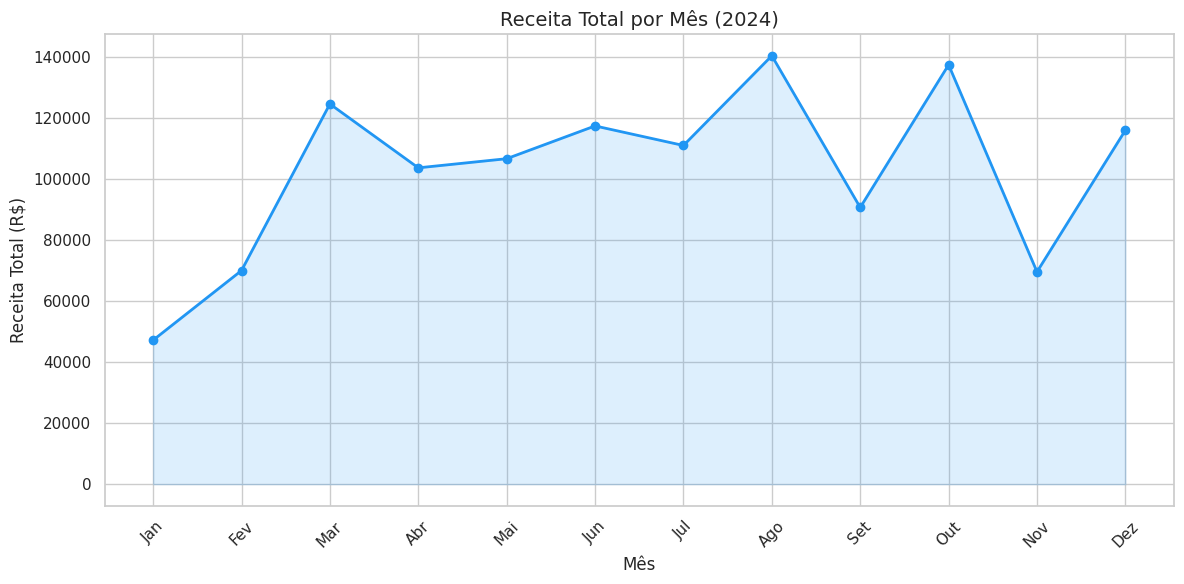

 Gráfico exportado: outputs/graficos/vendas_por_mes.png



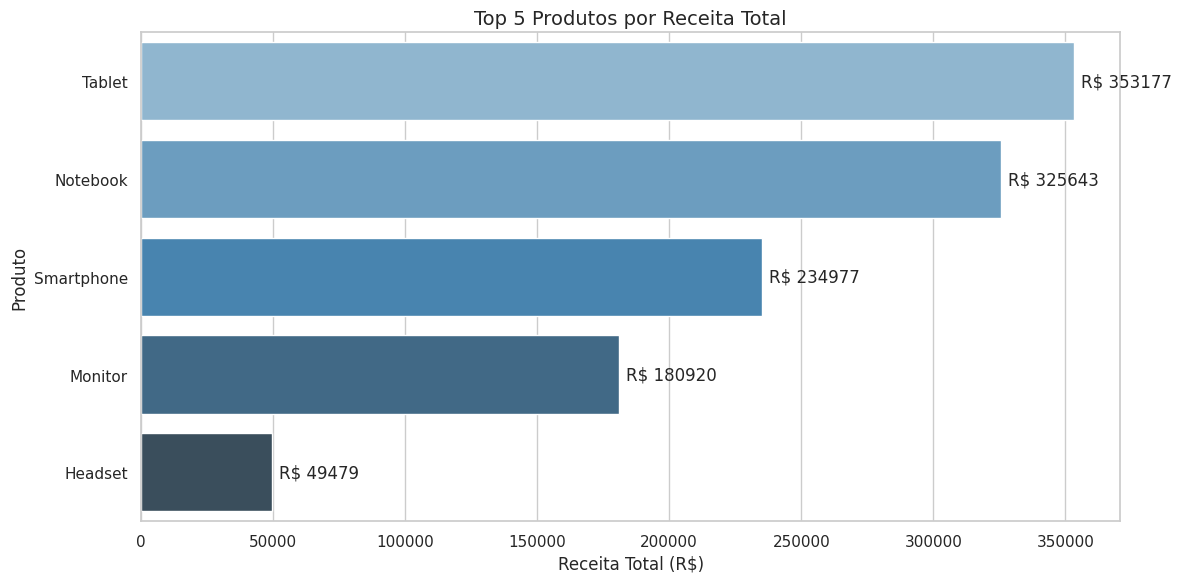

 Gráfico exportado: outputs/graficos/top_produtos.png



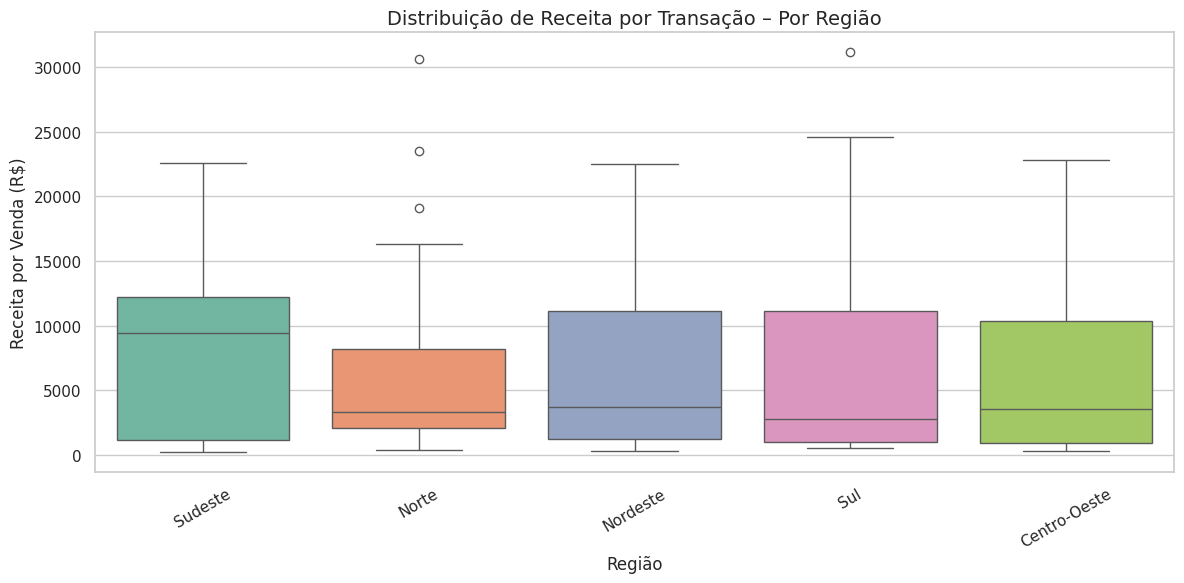

 Gráfico exportado: outputs/graficos/distribuicao_regioes.png

=== VISUALIZAÇÕES GERADAS E EXPORTADAS COM SUCESSO ===


In [11]:
si.gerar_visualizacoes(df_processado, metricas_finais)

Etapa 9 - Demonstração do uso do conceito de Herança
"""
Como uma classe pode herdar de outra classe e receber novas funcionalidades."

In [12]:
from SalesInsight import SalesProjection

sp = SalesProjection(pd, np, meses_projecao=6)
sp.projetar_tendencia(df_processado)
sp.exibir_projecao_detalhada()


=== POR MES ===
 mes  receita_total  quantidade  n_vendas
   1       47169.34          45         9
   2       69968.85          91        15
   3      124532.20          88        17
   4      103611.52          75        15
   5      106602.03          89        14
   6      117334.85          75        15
   7      110935.66          99        19
   8      140320.55          81        13
   9       90627.26          63        10
  10      137350.13         118        20
  11       69554.97          65        12
  12      115925.56         105        21

=== TOP PRODUTOS ===
   produto  receita_total
    Tablet      353176.81
  Notebook      325642.80
Smartphone      234977.18
   Monitor      180920.09
   Headset       49479.31

=== POR CATEGORIA ===
   categoria  receita_total
   Celulares      588153.99
Computadores      540679.29
 Periféricos      105099.64

=== POR REGIAO ===
      regiao  receita_total  media_ticket
     Sudeste      329458.34   8447.649744
Centro-Oeste      24

Etapa 11 - Usando Funções Lambda e Funções de Ordem Superior
"""
Uso de funções lambda e demonstração de uma função que recebe outra como parâmetro (equivalente ao conceito de callback)"""

In [13]:
# Lambda em apply (transformação condicional de coluna)
df_processado["desconto"] = df_processado["receita_total"].apply(lambda x: 0.10 if x > 10000 else 0.05)

# Lambda como filtro rápido
vendas_alto_valor = df_processado[df_processado["receita_total"].apply(lambda x: x > 5000)]

print("=== EXEMPLOS DE FUNÇÕES LAMBDA ===")
print("\nDataFrame com coluna 'desconto':")
display(df_processado[['receita_total', 'desconto']].head())

print("\nVendas de alto valor (primeiras 5 linhas):")
display(vendas_alto_valor.head())

=== EXEMPLOS DE FUNÇÕES LAMBDA ===

DataFrame com coluna 'desconto':


,receita_total,desconto
0,205.80,0.05
1,1504.16,0.05
3,10007.04,0.10
4,970.40,0.05
5,3800.48,0.05



Vendas de alto valor (primeiras 5 linhas):


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,receita_total,mes,mes_nome,trimestre,ano,faixa_receita_item,desconto
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4,2501.76,10007.04,6,June,Q2,2024,Alto Valor,0.10
6,7,2024-06-30,Cliente_039,Monitor,Computadores,Sul,6,1078.56,6471.36,6,June,Q2,2024,Alto Valor,0.05
10,11,2024-04-22,Cliente_008,Monitor,Computadores,Sul,10,1163.78,11637.80,4,April,Q2,2024,Alto Valor,0.10
15,16,2024-07-04,Cliente_037,Tablet,Celulares,Sudeste,8,1540.52,12324.16,7,July,Q3,2024,Alto Valor,0.10
16,17,2024-09-29,Cliente_017,Notebook,Computadores,Norte,8,3831.82,30654.56,9,September,Q3,2024,Alto Valor,0.10


In [14]:
# Uso da função com lambda como callback
print("=== EXEMPLOS DE FUNÇÕES DE ORDEM SUPERIOR E LAMBDA ===")
df_processado = si.processar_coluna(df_processado.copy(), "receita_total", lambda x: round(x / 1000, 2))
display(df_processado[['receita_total', 'receita_total_transformado']].head())

df_processado = si.processar_coluna(df_processado.copy(), "quantidade", lambda x: "Alto" if x > 5 else "Baixo")
display(df_processado[['quantidade', 'quantidade_transformado']].head())

=== EXEMPLOS DE FUNÇÕES DE ORDEM SUPERIOR E LAMBDA ===
  Coluna 'receita_total_transformado' criada com sucesso.


,receita_total,receita_total_transformado
0,205.80,0.21
1,1504.16,1.50
3,10007.04,10.01
4,970.40,0.97
5,3800.48,3.80


  Coluna 'quantidade_transformado' criada com sucesso.


,quantidade,quantidade_transformado
0,2,Baixo
1,7,Alto
3,4,Baixo
4,8,Alto
5,2,Baixo


Etapa 12 - Leitura e criação de arquivos CSV e JSON


In [15]:
si.exportar_resultados(metricas_finais, clientes_segmentados, estatisticas_numpy)

  CSV exportado: outputs/metricas_por_mes.csv
  CSV exportado: outputs/segmentacao_clientes.csv
  JSON exportado: outputs/estatisticas_gerais.json

  Conteúdo do JSON exportado:
  {
  "media": 6855.18,
  "mediana": 3899.61,
  "desvio_padrao": 6673.94,
  "total": 1233932.92
}


Etapa 13 - Utilizando expressoes regulares para limpeza de dados
"""
Agora iremos importar e usar o módulo re para executar a limpeza ou validação de dados com expressões regulares"""

In [16]:
df_com_regex_limpo = si.limpar_strings_com_regex(dataset_vendas.copy())
display(df_com_regex_limpo.head())


=== LIMPEZA COM REGEX ===
  Clientes com formato inválido encontrados: 0
  Amostra de clientes limpos: ['Cliente_035', 'Cliente_042', 'Cliente_022', 'Cliente_017', 'Cliente_024']


,id_venda,data_venda,cliente,produto,categoria,regiao,quantidade,preco_unitario,cliente_limpo,cliente_valido
0,1,2024-05-20,Cliente_035,Mouse,Periféricos,Sudeste,2.0,102.90,Cliente_035,True
1,2,2024-02-17,Cliente_042,Teclado,Periféricos,Norte,7.0,214.88,Cliente_042,True
2,3,2024-05-22,Cliente_022,Monitor,Computadores,Nordeste,4.0,NaN,Cliente_022,True
3,4,2024-06-21,Cliente_017,Smartphone,Celulares,Sudeste,4.0,2501.76,Cliente_017,True
4,5,2024-07-12,Cliente_024,Mouse,Periféricos,Norte,8.0,121.30,Cliente_024,True
